CELDA 1 — Montar Google Drive

Montamos Drive dentro del sistema de archivos de Colab para acceder a la base de datos presente en el drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


CELDA 2 — Importar librerías
Esta celda carga todas las librerías que se van a usar durante el entrenamiento.

Lo consigue gracias a varias herramientas:

os, shutil, Path:
Sirven para manejar archivos, carpetas, rutas y copias de imágenes.

random, numpy:
Sirven para controlar aleatoriedad y trabajar con arrays numéricos.

matplotlib:
Sirve para dibujar gráficas de entrenamiento y matriz de confusión.

tensorflow y keras:
Sirven para cargar imágenes, construir la red neuronal, entrenarla y guardarla.

sklearn:
Sirve para dividir el dataset, calcular pesos de clase y obtener métricas como precision, recall, F1-score y matriz de confusión.

In [ ]:
import os
import shutil
import random
from pathlib import Path
import time

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

CELDA 3 — Comprobar GPU disponible

Comprobamos si hay una GPU disponible para el entrenamiento del modelo
Esto lo hacemos porque, en el caso de que no hubiera una GPU asignada, el entrenamiento tardaria mucho.

In [ ]:
gpus = tf.config.list_physical_devices("GPU")

print("GPUs disponibles:", gpus)

if len(gpus) == 0:
    print("AVISO: No se ha detectado GPU. El entrenamiento puede tardar mucho.")
else:
    print("GPU detectada correctamente.")

GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU detectada correctamente.


CELDA 4 — Configuración general
Aquí se configuran:

La semilla:

SEMILLA = 42

Sirve para intentar que las divisiones del dataset y ciertos procesos aleatorios sean reproducibles.

Las rutas:

RUTA_DATASET_ORIGINAL
Indica dónde está el dataset original en Drive.

RUTA_DATASET_PROCESADO
Indica dónde se creará una copia organizada en entrenamiento, validación y test.

RUTA_CARPETA_MODELOS
Indica dónde se guardarán los modelos entrenados.

Las clases: CLASES = ["COVID", "Normal", "Viral Pneumonia"]

Esto le dice al programa que solo va a entrenar con esas tres clases.

Los parámetros del entrenamiento:

TAMANO_IMAGEN = (256, 256)
Las imágenes se cargarán con tamaño 256x256.

TAMANO_LOTE = 16
El modelo entrenará procesando 16 imágenes cada vez.

EPOCAS = 30
El entrenamiento podrá durar hasta 30 vueltas completas sobre el dataset.

Para comprobar si el modelo funciona y no estar mucho tiempo, primero se hace una prueba de 2 vueltas
EPOCAS = 2

Las proporciones: 70% entrenamiento, 15% validación y 15% test.


También crea la carpeta de modelos gracias a: mkdir(parents=True, exist_ok=True)

Eso evita errores si la carpeta todavía no existe.

In [ ]:
SEMILLA = 42

random.seed(SEMILLA)
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)

# Dataset combinado con las imágenes del primer y segundo dataset.
RUTA_DATASET_ORIGINAL = Path(
    "/content/drive/MyDrive/TFG/Copia 1 dataset"
)

# Carpeta temporal de trabajo dentro de Colab.
RUTA_TRABAJO = Path("/content/datos_radiografias_2_datasets")
RUTA_DATASET_PROCESADO = RUTA_TRABAJO / "procesado"

# Carpeta de guardado exclusiva para el modelo con 2 datasets.
RUTA_CARPETA_MODELOS = Path(
    "/content/drive/MyDrive/TFG/modelos con 2 datasets"
)

RUTA_CARPETA_MODELOS.mkdir(parents=True, exist_ok=True)

RUTA_MEJOR_MODELO = (
    RUTA_CARPETA_MODELOS / "mejor_modelo_radiografias_2_datasets.keras"
)

RUTA_MODELO_FINAL = (
    RUTA_CARPETA_MODELOS / "modelo_final_radiografias_2_datasets.keras"
)

RUTA_METADATA = (
    RUTA_CARPETA_MODELOS / "metadata_radiografias_2_datasets.csv"
)

CLASES = [
    "COVID",
    "Normal",
    "Viral Pneumonia",
    "Bacterial Pneumonia"
]

TAMANO_IMAGEN = (256, 256)
TAMANO_LOTE = 16
EPOCAS = 30

EXTENSIONES_VALIDAS = {".png", ".jpg", ".jpeg"}

PORCENTAJE_ENTRENAMIENTO = 0.70
PORCENTAJE_VALIDACION = 0.15
PORCENTAJE_TEST = 0.15

# Usamos todas las imágenes disponibles.
MAX_IMAGENES_POR_CLASE = None
LIMITAR_CLASE_NORMAL = False

# Aumento de datos suave.
USAR_AUMENTO_DATOS = True

# Estratificación por origen para repartir dataset_principal y dataset_extra.
USAR_ESTRATIFICACION_POR_ORIGEN = True

# Sobremuestreo específico para mejorar Viral Pneumonia del dataset_extra.
# Solo se aplica en entrenamiento.
USAR_SOBREMUESTREO_VIRAL_EXTRA = True
FACTOR_SOBREMUESTREO_VIRAL_EXTRA = 2

print("Dataset usado:")
print(RUTA_DATASET_ORIGINAL)

print("\nModelos guardados en:")
print(RUTA_CARPETA_MODELOS)

print("\nMejor modelo:")
print(RUTA_MEJOR_MODELO)

print("\nModelo final:")
print(RUTA_MODELO_FINAL)

print("\nMetadata:")
print(RUTA_METADATA)

print("\nClases:")
print(CLASES)

print("\nSobremuestreo Viral Pneumonia dataset_extra:")
print("Activo:", USAR_SOBREMUESTREO_VIRAL_EXTRA)
print("Factor:", FACTOR_SOBREMUESTREO_VIRAL_EXTRA)

Dataset usado:
/content/drive/MyDrive/TFG/Copia 1 dataset

Modelos guardados en:
/content/drive/MyDrive/TFG/modelos con 2 datasets

Mejor modelo:
/content/drive/MyDrive/TFG/modelos con 2 datasets/mejor_modelo_radiografias_2_datasets.keras

Modelo final:
/content/drive/MyDrive/TFG/modelos con 2 datasets/modelo_final_radiografias_2_datasets.keras

Metadata:
/content/drive/MyDrive/TFG/modelos con 2 datasets/metadata_radiografias_2_datasets.csv

Clases:
['COVID', 'Normal', 'Viral Pneumonia', 'Bacterial Pneumonia']

Sobremuestreo Viral Pneumonia dataset_extra:
Activo: True
Factor: 2


CELDA 5 — Comprobar que el dataset existe

Esta celda comprueba que la ruta del dataset es correcta.

Lo consigue gracias a:

RUTA_DATASET_ORIGINAL.exists()

Esa función verifica si la carpeta existe realmente, después usa iterdir() para listar el contenido de la carpeta.

Esta celda es importante porque si la ruta está mal, el entrenamiento no puede empezar. Es mejor detectar ese error al principio que descubrirlo más adelante.

Aquí se deberían ver carpetas como:

COVID
Normal
Viral Pneumonia
Lung_Opacity

Aunque aparezca Lung_Opacity, no se usará pues no esta incluida en la variable CLASES

In [ ]:
if not RUTA_DATASET_ORIGINAL.exists():
    raise FileNotFoundError(
        f"No existe la ruta del dataset: {RUTA_DATASET_ORIGINAL}"
    )

print("Contenido del dataset combinado:")

for elemento in RUTA_DATASET_ORIGINAL.iterdir():
    print("-", elemento.name)

print("\nConteo inicial de imágenes por clase:")

for nombre_clase in CLASES:
    ruta_clase = RUTA_DATASET_ORIGINAL / nombre_clase

    if not ruta_clase.exists():
        print(nombre_clase, ": NO EXISTE")
        continue

    ruta_imagenes = ruta_clase / "images"

    if ruta_imagenes.exists():
        ruta_busqueda = ruta_imagenes
    else:
        ruta_busqueda = ruta_clase

    imagenes = [
        archivo for archivo in ruta_busqueda.rglob("*")
        if archivo.is_file()
        and archivo.suffix.lower() in EXTENSIONES_VALIDAS
        and "mask" not in str(archivo).lower()
        and "masks" not in str(archivo).lower()
    ]

    print(nombre_clase, ":", len(imagenes))

Contenido del dataset combinado:
- COVID
- Normal
- Viral Pneumonia
- Bacterial Pneumonia

Conteo inicial de imágenes por clase:
COVID : 3616
Normal : 11263
Viral Pneumonia : 2370
Bacterial Pneumonia : 1898


CELDA 6 — Funciones para preparar carpetas e imágenes

Esta celda define dos funciones:

La primera:

reiniciar_carpeta, borra una carpeta si ya existe y la vuelve a crear vacía.

La segunda:

listar_imagenes_clase, busca las imágenes dentro de cada carpeta de clase.

Lo importante es que contempla dos posibles estructuras del dataset.

Primero busca aquí:

COVID/images/
Normal/images/
Viral Pneumonia/images/

Si no existe images, busca directamente aquí:

COVID/
Normal/
Viral Pneumonia/

Esto es importante porque el dataset de Kaggle puede venir con subcarpetas images y masks. Nosotros solo necesitamos las imágenes, no las máscaras.

También filtra por extensión usando:

EXTENSIONES_VALIDAS = {".png", ".jpg", ".jpeg"}

Así evita coger archivos que no sean imágenes válidas.

In [ ]:
def reiniciar_carpeta(ruta: Path):
    if ruta.exists():
        shutil.rmtree(ruta)

    ruta.mkdir(parents=True, exist_ok=True)


def listar_imagenes_clase(ruta_clase: Path):
    ruta_imagenes = ruta_clase / "images"

    if ruta_imagenes.exists():
        ruta_busqueda = ruta_imagenes
    else:
        ruta_busqueda = ruta_clase

    imagenes = [
        archivo for archivo in ruta_busqueda.rglob("*")
        if archivo.is_file()
        and archivo.suffix.lower() in EXTENSIONES_VALIDAS
        and "mask" not in str(archivo).lower()
        and "masks" not in str(archivo).lower()
    ]

    return imagenes


def detectar_origen_imagen(ruta_imagen: Path):
    nombre = ruta_imagen.name.lower()

    if nombre.startswith("extra_") or "_extra_" in nombre:
        return "dataset_extra"

    return "dataset_principal"


def dividir_registros_con_origen(registros_clase):
    origenes = [registro["origen"] for registro in registros_clase]

    usar_stratify = False

    if USAR_ESTRATIFICACION_POR_ORIGEN:
        valores_origen, conteos_origen = np.unique(
            origenes,
            return_counts=True
        )

        if len(valores_origen) > 1 and np.min(conteos_origen) >= 2:
            usar_stratify = True

    stratify_primer_corte = origenes if usar_stratify else None

    try:
        registros_entrenamiento, registros_temporales = train_test_split(
            registros_clase,
            test_size=(1 - PORCENTAJE_ENTRENAMIENTO),
            random_state=SEMILLA,
            shuffle=True,
            stratify=stratify_primer_corte
        )
    except ValueError:
        registros_entrenamiento, registros_temporales = train_test_split(
            registros_clase,
            test_size=(1 - PORCENTAJE_ENTRENAMIENTO),
            random_state=SEMILLA,
            shuffle=True
        )

    origenes_temporales = [
        registro["origen"]
        for registro in registros_temporales
    ]

    usar_stratify_temporal = False

    if USAR_ESTRATIFICACION_POR_ORIGEN:
        valores_origen_temp, conteos_origen_temp = np.unique(
            origenes_temporales,
            return_counts=True
        )

        if len(valores_origen_temp) > 1 and np.min(conteos_origen_temp) >= 2:
            usar_stratify_temporal = True

    stratify_segundo_corte = (
        origenes_temporales
        if usar_stratify_temporal
        else None
    )

    try:
        registros_validacion, registros_test = train_test_split(
            registros_temporales,
            test_size=(
                PORCENTAJE_TEST
                / (PORCENTAJE_VALIDACION + PORCENTAJE_TEST)
            ),
            random_state=SEMILLA,
            shuffle=True,
            stratify=stratify_segundo_corte
        )
    except ValueError:
        registros_validacion, registros_test = train_test_split(
            registros_temporales,
            test_size=(
                PORCENTAJE_TEST
                / (PORCENTAJE_VALIDACION + PORCENTAJE_TEST)
            ),
            random_state=SEMILLA,
            shuffle=True
        )

    return registros_entrenamiento, registros_validacion, registros_test


def aplicar_sobremuestreo_viral_extra(registros_entrenamiento, nombre_clase):
    """
    Sobremuestrea únicamente las imágenes de Viral Pneumonia procedentes
    del dataset_extra dentro del conjunto de entrenamiento.

    No modifica validación ni test.

    Si FACTOR_SOBREMUESTREO_VIRAL_EXTRA = 2, cada imagen viral extra
    aparece dos veces en entrenamiento: la original + una copia adicional.
    """

    if not USAR_SOBREMUESTREO_VIRAL_EXTRA:
        return registros_entrenamiento

    if nombre_clase != "Viral Pneumonia":
        return registros_entrenamiento

    registros_viral_extra = [
        registro for registro in registros_entrenamiento
        if registro["clase"] == "Viral Pneumonia"
        and registro["origen"] == "dataset_extra"
    ]

    if len(registros_viral_extra) == 0:
        print(
            "No se encontraron imágenes de Viral Pneumonia del dataset_extra "
            "en entrenamiento."
        )
        return registros_entrenamiento

    registros_aumentados = list(registros_entrenamiento)

    numero_copias_extra = FACTOR_SOBREMUESTREO_VIRAL_EXTRA - 1

    for repeticion in range(numero_copias_extra):
        for registro in registros_viral_extra:
            nuevo_registro = {
                "ruta": registro["ruta"],
                "clase": registro["clase"],
                "origen": registro["origen"],
                "sobremuestreado": True,
                "repeticion_sobremuestreo": repeticion + 1
            }

            registros_aumentados.append(nuevo_registro)

    print("\nSobremuestreo aplicado a Viral Pneumonia del dataset_extra")
    print("Viral extra originales en entrenamiento:", len(registros_viral_extra))
    print("Factor de sobremuestreo:", FACTOR_SOBREMUESTREO_VIRAL_EXTRA)
    print("Total entrenamiento antes:", len(registros_entrenamiento))
    print("Total entrenamiento después:", len(registros_aumentados))

    return registros_aumentados

CELDA 7 — Crear particiones entrenamiento / validación / test
Distribuye las imagenes en 3 carpetas:

Imagenes de entrenamiento:
Estaran compuestas por el 70% de la base de datos, su funcion es entrenar al modelo

Inagenes de Validacion:
Corresponden al 15% de las imagenes de la base de datos, sirven para detectar sobreajustes o para detectar si el modelo mejora o no, los usaremos en celdas mas adelante

Imagenes de test:
Estan formadas por el 15% restante y son utilizadas para evaluar el rendimiento del modelo una vez entrenado, es lo que nos ayuda a detectar el accuracy y diversos datos del modelo.

In [ ]:
inicio_particionado = time.time()

reiniciar_carpeta(RUTA_DATASET_PROCESADO)

for particion in ["entrenamiento", "validacion", "test"]:
    for nombre_clase in CLASES:
        ruta_destino = RUTA_DATASET_PROCESADO / particion / nombre_clase
        ruta_destino.mkdir(parents=True, exist_ok=True)

registros_metadata = []

for nombre_clase in CLASES:
    ruta_clase = RUTA_DATASET_ORIGINAL / nombre_clase

    if not ruta_clase.exists():
        raise FileNotFoundError(f"No existe la carpeta de clase: {ruta_clase}")

    imagenes = listar_imagenes_clase(ruta_clase)

    if len(imagenes) == 0:
        raise ValueError(f"No se encontraron imágenes para la clase: {nombre_clase}")

    registros_clase = []

    for imagen in imagenes:
        registros_clase.append({
            "ruta": imagen,
            "clase": nombre_clase,
            "origen": detectar_origen_imagen(imagen),
            "sobremuestreado": False,
            "repeticion_sobremuestreo": 0
        })

    if (
        MAX_IMAGENES_POR_CLASE is not None
        and len(registros_clase) > MAX_IMAGENES_POR_CLASE
    ):
        random.shuffle(registros_clase)
        registros_clase = registros_clase[:MAX_IMAGENES_POR_CLASE]

    registros_entrenamiento, registros_validacion, registros_test = dividir_registros_con_origen(
        registros_clase
    )

    registros_entrenamiento = aplicar_sobremuestreo_viral_extra(
        registros_entrenamiento=registros_entrenamiento,
        nombre_clase=nombre_clase
    )

    particiones = {
        "entrenamiento": registros_entrenamiento,
        "validacion": registros_validacion,
        "test": registros_test
    }

    for nombre_particion, lista_registros in particiones.items():
        print(
            f"\nCopiando {nombre_clase} - {nombre_particion}: "
            f"{len(lista_registros)} imágenes",
            flush=True
        )

        for indice, registro in enumerate(lista_registros):
            imagen = registro["ruta"]
            clase = registro["clase"]
            origen = registro["origen"]
            sobremuestreado = registro.get("sobremuestreado", False)
            repeticion_sobremuestreo = registro.get("repeticion_sobremuestreo", 0)

            nombre_clase_limpio = clase.replace(" ", "_")
            nombre_origen_limpio = origen.replace(" ", "_")
            nombre_original_limpio = imagen.name.replace(" ", "_")

            if sobremuestreado:
                prefijo_sobremuestreo = f"oversampling_{repeticion_sobremuestreo}_"
            else:
                prefijo_sobremuestreo = ""

            nuevo_nombre = (
                f"{nombre_origen_limpio}_"
                f"{nombre_clase_limpio}_"
                f"{prefijo_sobremuestreo}"
                f"{indice}_"
                f"{nombre_original_limpio}"
            )

            destino = (
                RUTA_DATASET_PROCESADO
                / nombre_particion
                / clase
                / nuevo_nombre
            )

            shutil.copyfile(imagen, destino)

            registros_metadata.append({
                "particion": nombre_particion,
                "clase": clase,
                "origen": origen,
                "sobremuestreado": sobremuestreado,
                "repeticion_sobremuestreo": repeticion_sobremuestreo,
                "ruta_original": str(imagen),
                "ruta_procesada": str(destino)
            })

            if (indice + 1) % 500 == 0 or (indice + 1) == len(lista_registros):
                tiempo_transcurrido = time.time() - inicio_particionado

                print(
                    f"{nombre_clase} - {nombre_particion}: "
                    f"{indice + 1}/{len(lista_registros)} copiadas | "
                    f"Tiempo: {tiempo_transcurrido / 60:.2f} min",
                    flush=True
                )

    print(f"\nClase: {nombre_clase}")
    print("  Total usado antes de particionar:", len(registros_clase))
    print("  Entrenamiento después de sobremuestreo:", len(registros_entrenamiento))
    print("  Validación:", len(registros_validacion))
    print("  Test:", len(registros_test))

    print("  Origen en entrenamiento:")
    print(pd.Series([r["origen"] for r in registros_entrenamiento]).value_counts())

    print("  Origen en validación:")
    print(pd.Series([r["origen"] for r in registros_validacion]).value_counts())

    print("  Origen en test:")
    print(pd.Series([r["origen"] for r in registros_test]).value_counts())

    print("  Imágenes sobremuestreadas en entrenamiento:")
    print(pd.Series([r.get("sobremuestreado", False) for r in registros_entrenamiento]).value_counts())

df_metadata = pd.DataFrame(registros_metadata)

df_metadata.to_csv(RUTA_METADATA, index=False)

print("\nMetadata guardada en:")
print(RUTA_METADATA)

print("\nTiempo total de particionado:")
print(f"{(time.time() - inicio_particionado) / 60:.2f} minutos")





Copiando COVID - entrenamiento: 2531 imágenes
COVID - entrenamiento: 500/2531 copiadas | Tiempo: 1.20 min
COVID - entrenamiento: 1000/2531 copiadas | Tiempo: 1.23 min
COVID - entrenamiento: 1500/2531 copiadas | Tiempo: 1.25 min
COVID - entrenamiento: 2000/2531 copiadas | Tiempo: 1.27 min
COVID - entrenamiento: 2500/2531 copiadas | Tiempo: 1.29 min
COVID - entrenamiento: 2531/2531 copiadas | Tiempo: 1.29 min

Copiando COVID - validacion: 542 imágenes
COVID - validacion: 500/542 copiadas | Tiempo: 1.31 min
COVID - validacion: 542/542 copiadas | Tiempo: 1.31 min

Copiando COVID - test: 543 imágenes
COVID - test: 500/543 copiadas | Tiempo: 1.33 min
COVID - test: 543/543 copiadas | Tiempo: 1.33 min

Clase: COVID
  Total usado antes de particionar: 3616
  Entrenamiento después de sobremuestreo: 2531
  Validación: 542
  Test: 543
  Origen en entrenamiento:
dataset_principal    2531
Name: count, dtype: int64
  Origen en validación:
dataset_principal    542
Name: count, dtype: int64
  Origen e

In [ ]:
for particion in ["entrenamiento", "validacion", "test"]:
    print("\nPartición:", particion)

    for nombre_clase in CLASES:
        ruta = RUTA_DATASET_PROCESADO / particion / nombre_clase

        imagenes = [
            archivo for archivo in ruta.iterdir()
            if archivo.is_file()
            and archivo.suffix.lower() in EXTENSIONES_VALIDAS
        ]

        print(nombre_clase, ":", len(imagenes))


print("\nDistribución por origen, partición y clase:")

df_metadata = pd.read_csv(RUTA_METADATA)

distribucion_origen = (
    df_metadata
    .groupby(["particion", "origen", "clase"])
    .size()
    .reset_index(name="cantidad")
)

display(distribucion_origen)


Partición: entrenamiento
COVID : 2531
Normal : 7884
Viral Pneumonia : 2375
Bacterial Pneumonia : 1328

Partición: validacion
COVID : 542
Normal : 1689
Viral Pneumonia : 356
Bacterial Pneumonia : 285

Partición: test
COVID : 543
Normal : 1690
Viral Pneumonia : 356
Bacterial Pneumonia : 285

Distribución por origen, partición y clase:


,particion,origen,clase,cantidad
0,entrenamiento,dataset_extra,Bacterial Pneumonia,1328
1,entrenamiento,dataset_extra,Normal,750
2,entrenamiento,dataset_extra,Viral Pneumonia,1434
3,entrenamiento,dataset_principal,COVID,2531
4,entrenamiento,dataset_principal,Normal,7134
5,entrenamiento,dataset_principal,Viral Pneumonia,941
6,test,dataset_extra,Bacterial Pneumonia,285
7,test,dataset_extra,Normal,161
8,test,dataset_extra,Viral Pneumonia,154
9,test,dataset_principal,COVID,543


CELDA 8 — Cargar datasets con TensorFlow
Una vez separados los datos en las diferentes carpetas, se usa TensorFlow y keras, en concreto

tf.keras.utils.image_dataset_from_directory

Esta funcion lee las subcarpetas (COVID, normal, Viral Pneumonia) dentro de cada clase, y las interpreta como una etiqueta y las asigna un numero para identificarlas, ademas las carga todas con el mismo color y el mismo tamaño y las agrupa de 16 en 16



In [ ]:
dataset_entrenamiento = tf.keras.utils.image_dataset_from_directory(
    str(RUTA_DATASET_PROCESADO / "entrenamiento"),
    labels="inferred",
    label_mode="int",
    class_names=CLASES,
    color_mode="grayscale",
    image_size=TAMANO_IMAGEN,
    batch_size=TAMANO_LOTE,
    shuffle=True,
    seed=SEMILLA
)

dataset_validacion = tf.keras.utils.image_dataset_from_directory(
    str(RUTA_DATASET_PROCESADO / "validacion"),
    labels="inferred",
    label_mode="int",
    class_names=CLASES,
    color_mode="grayscale",
    image_size=TAMANO_IMAGEN,
    batch_size=TAMANO_LOTE,
    shuffle=False
)

dataset_test = tf.keras.utils.image_dataset_from_directory(
    str(RUTA_DATASET_PROCESADO / "test"),
    labels="inferred",
    label_mode="int",
    class_names=CLASES,
    color_mode="grayscale",
    image_size=TAMANO_IMAGEN,
    batch_size=TAMANO_LOTE,
    shuffle=False
)

RUTAS_TEST = list(dataset_test.file_paths)

print("Clases detectadas:", dataset_entrenamiento.class_names)
print("Número de rutas de test guardadas:", len(RUTAS_TEST))


Found 14118 files belonging to 4 classes.
Found 2872 files belonging to 4 classes.
Found 2874 files belonging to 4 classes.
Clases detectadas: ['COVID', 'Normal', 'Viral Pneumonia', 'Bacterial Pneumonia']
Número de rutas de test guardadas: 2874


CELDA 9 — Comprobar forma de las imágenes

Esta celda toma un lote de imágenes del dataset de entrenamiento y muestra su forma, la usamos para comprobar que la celda anterior cumple su funcion.

In [ ]:
for imagenes_ejemplo, etiquetas_ejemplo in dataset_entrenamiento.take(1):
    print("Forma del lote de imágenes:", imagenes_ejemplo.shape)
    print("Forma del lote de etiquetas:", etiquetas_ejemplo.shape)
    print("Tipo de dato de las imágenes:", imagenes_ejemplo.dtype)
    print("Primeras etiquetas:", etiquetas_ejemplo.numpy()[:10])

Forma del lote de imágenes: (16, 256, 256, 1)
Forma del lote de etiquetas: (16,)
Tipo de dato de las imágenes: <dtype: 'float32'>
Primeras etiquetas: [1 0 1 2 0 2 1 1 1 2]


CELDA 10 — Optimizar carga de datos

Esto es una optimizacion sujerida por la IA devido a la gran cantidad de tiempo que tarda en entrenarse este tipo de modelos, basicamente, miemtras se entrena al modelo con un lote de imagenes, se va cargando otro, no se espera a que se termine el entrenamiento.

In [ ]:

AUTOAJUSTE = tf.data.AUTOTUNE

dataset_entrenamiento = dataset_entrenamiento.prefetch(AUTOAJUSTE)
dataset_validacion = dataset_validacion.prefetch(AUTOAJUSTE)
dataset_test = dataset_test.prefetch(AUTOAJUSTE)


CELDA 11 — Calcular pesos de clase

Cuando he estado entrenando el modelo con anterioridad, he notado que existe un desbalanceo de muestras de clases, en especifico, de Normal, esto puede hacer que la calidad del modelo sea peor,lo que usamos para corregirlo es:
compute_class_weightde sklearn.

Primero recorre todas las etiquetas del dataset de entrenamiento, después calcula qué peso debe tener cada clase, y, si una clase tiene pocas imágenes, recibe más peso y si una clase tiene muchas imágenes, recibe menos peso.

Así, durante el entrenamiento, los errores en clases minoritarias tienen más importancia.

In [ ]:
etiquetas_entrenamiento = []

for _, etiquetas in dataset_entrenamiento.unbatch():
    etiquetas_entrenamiento.append(int(etiquetas.numpy()))

etiquetas_entrenamiento = np.array(etiquetas_entrenamiento)

clases_numericas = np.unique(etiquetas_entrenamiento)

pesos_clases_array = compute_class_weight(
    class_weight="balanced",
    classes=clases_numericas,
    y=etiquetas_entrenamiento
)

pesos_clases = {
    int(clase): float(peso)
    for clase, peso in zip(clases_numericas, pesos_clases_array)
}

print("Pesos de clase:", pesos_clases)

print("\nDistribución de entrenamiento:")

for indice, nombre_clase in enumerate(CLASES):
    cantidad = np.sum(etiquetas_entrenamiento == indice)
    print(indice, "-", nombre_clase, ":", cantidad, "imágenes")


Pesos de clase: {0: 1.3945080995653891, 1: 0.4476788432267884, 2: 1.4861052631578948, 3: 2.6577560240963853}

Distribución de entrenamiento:
0 - COVID : 2531 imágenes
1 - Normal : 7884 imágenes
2 - Viral Pneumonia : 2375 imágenes
3 - Bacterial Pneumonia : 1328 imágenes


CELDA 12 — Bloque convolucional

Esta celda define una función llamada bloque_convolucional, la cual extrae caracteristicas visuales de las radiografias, la usaremos varias veces cuando construyamos el modelo, es
 Ej: (bordes, zonas claras, zonas oscuras, texturas o formas), esto lo consigue usando diferentes capas de Keras, las cuales definimos a continuacion:

 Conv2D

 Se encarga de aplicar filtros sobre la imagen, estos, detectan patrones como bordes, lineas cambios de intensidad, hemos definido la variable filtros en 32, despues, definimos que miran esos filtros, en este caso , les hemos dicho que zonas pequeñas de las foros, un 3x3, y hacemos que mantengan su tamaño y que aprendan patrones mas complejos gracias a padding y activation relu.

 BatchNormalization

 Despes de cada convolucion aplicada por Conv2D, el modelo a veces se desestabiliza, lo que hace BatchNormalization es nmormalizar el modelo, para que el entrenamiento se lo mas estable posible.

 MaxPooling2D

 El modelo no necesita tener la imagen entera una vez se ha aplicado la convolucion, lo que hace esta funcion es resumir info para agilizar el entrenamiento

 Dropout

 Se usa para evitar sobreajuste, que consiste en que el modelo se acostumbra a las imagenes del modelo y acaba funcionando peor con las imagenes nuevas


In [ ]:
def bloque_convolucional(x, filtros, repeticiones, nombre_bloque):
    entrada_bloque = x

    for indice in range(repeticiones):
        x = layers.Conv2D(filtros,(3, 3),padding="same",use_bias=False,name=f"{nombre_bloque}_conv_{indice + 1}")(x)

        x = layers.BatchNormalization(name=f"{nombre_bloque}_bn_{indice + 1}")(x)

        x = layers.Activation("relu",name=f"{nombre_bloque}_relu_{indice + 1}")(x)

    canales_entrada = int(entrada_bloque.shape[-1])

    if canales_entrada != filtros:
        entrada_bloque = layers.Conv2D(filtros,(1, 1),padding="same",use_bias=False,name=f"{nombre_bloque}_proyeccion_residual")(entrada_bloque)

        entrada_bloque = layers.BatchNormalization(name=f"{nombre_bloque}_bn_proyeccion")(entrada_bloque)

    x = layers.Add(name=f"{nombre_bloque}_suma_residual")([x, entrada_bloque])

    x = layers.Activation("relu",name=f"{nombre_bloque}_relu_salida")(x)

    x = layers.MaxPooling2D(pool_size=(2, 2),name=f"{nombre_bloque}_max_pooling")(x)

    x = layers.Dropout(0.2,name=f"{nombre_bloque}_dropout")(x)

    return x

CELDA 13 — Bloque ASPP

Es una de las celdas mas importantes del modelo, es la que recibe las caracteristicas extraidas  por la funcion definida en la celda anterior, que se aplica varias veces en el modelo.

Una vez recibidos los datos extraidos de las otras capas, lo que hace esta capa es buscar patrones en varias escalas al mismo tiempo, para ello, usa ramas en las que se subdivide, en este caso 5, las 4 primeras ramas son muy parecidas, es aplicar el Conv2D ya aplicado en la anterior celda pero mirando cada vez una zona mas amplia, sienmdo la mas pequeña de un 1x1 y la mas grande un 6x6

Luego, la rama 5 intenta mirar la imagen desde un punto de visdta mas global usando GlobalAveragePooling2D, esto, cambia la forma de los datos, por lo que hay que hacer un Reshape, despues, aplica una convolucion a los datos y los reformatea para que tengan el mismo tamaño que las ramas del 1 al 4.

Por ultimo concatena las 5 ramas y se aplica una ultima convolucion de las 5 ramas ya concatenadas, pues al ser concatenadas, su tamaño se modifica y deben volver al tamaño pensado para ser tratadas por el modelo.

In [ ]:
def bloque_aspp(x):
    canales_entrada = int(x.shape[-1])

    rama_1 = layers.Conv2D(128,(1, 1),padding="same",activation="relu",name="aspp_conv_1x1")(x)

    rama_2 = layers.Conv2D(128,(3, 3),padding="same",dilation_rate=(2, 2),activation="relu",name="aspp_conv_d2")(x)

    rama_3 = layers.Conv2D(128,(3, 3),padding="same",dilation_rate=(4, 4),activation="relu",name="aspp_conv_d4")(x)

    rama_4 = layers.Conv2D(128,(3, 3),padding="same",dilation_rate=(6, 6),activation="relu",name="aspp_conv_d6")(x)

    rama_5 = layers.GlobalAveragePooling2D(name="aspp_gap")(x)

    rama_5 = layers.Reshape((1, 1, canales_entrada),name="aspp_gap_reshape")(rama_5)

    rama_5 = layers.Conv2D(128,(1, 1),padding="same",activation="relu",name="aspp_image_pool_conv")(rama_5)

    rama_5 = layers.UpSampling2D(size=(4, 4),interpolation="bilinear",name="aspp_upsample")(rama_5)

    x = layers.Concatenate(name="aspp_concat")([rama_1, rama_2, rama_3, rama_4, rama_5])

    x = layers.Conv2D(128,(1, 1),padding="same",activation="relu",name="aspp_projection")(x)

    return x

CELDA 14 — Bloque Squeeze-and-Excitation

Esta funcion, recibe los datos ya tratados por la celda ASPP, como sabemos, los datos han sido subdivididos en canales de cierto tamaño, que es con lo que hemops estado jugando tanto en la celda 12 como la 13, esta celda buscara decirle al modelo que canales son los mas importantes y cuales no debe mirar tanto.

Empieza haciendo una vision global de los canales del modelo usando GlobalAveragePooling2D, como haciamos en la rama 5 de la celda ASPP, despues, comprime los resultados dados por esta vision global usando layers.Dense, esto funciona como un cuello de botella, haciendo que el modelo deba aprender relaciones mas generales entre canales, es decir, aprende que canales condicionan a otros o cuales son los mas importantes a la hora de clasificar el modelo.

Despues, vuelve a expandir los canales comprimidos al estado normal pero los ordena segun la importancia de cada canal a la hora de identificar lo que se busca en el modelo a la hora de clasificar las imagenes.

Por ultimo, vuelve a dar a los canales el tamaño con el que habian entrado a la funcion que es el tamaño con el que se trabaja en el modelo.

In [ ]:
def bloque_squeeze_excitation(x):
    recalibrado = layers.GlobalAveragePooling2D(name="se_gap")(x)

    recalibrado = layers.Dense(8,activation="relu",name="se_dense_1")(recalibrado)

    recalibrado = layers.Dense(128,activation="sigmoid",name="se_dense_2")(recalibrado)

    recalibrado = layers.Reshape((1, 1, 128),name="se_reshape")(recalibrado)

    x = layers.Multiply(name="se_scale")([x, recalibrado])

    return x

CELDA 15 — Construcción completa del modelo

Aqui es donde se construye toda la arquitectura del modelo

Primero, se le dice al modelo donde encontrar las imagenes, despues, se tratan las imagenes para que esten a 128x128 que es como trabaja el modelo.

Despues se le aplican 5 bloques convolucionales, definidos en la celda 12.

En el primero, se aprenden los patrones mas simples, aplicandose menos filtros, cuantos mas filtros se van aplicando, mas se alejan los datos de la imagen, pero mejor clasifica el modelo la imagen pues extrae mas patrones de esta.

Despues, aplica la capa ASPP y la capa squeeze_excitation presentes en las celdas 13 y 14 respectivamente, dando una profundidad mayor a nuestro modelo.

Una vez los datos de las imagenes han pasado por todas las capas se hace un ultimo GlobalAveragePooling2D que convierte, como en la celda 14 los canales en un vector, lo que ayuda a la hora de clasificar la imagen.

Despues, usamos un dense para extraer las combinaciones de caracteristicas extraidas, es decir, que canal tiene peso para que clasificacion y en que medida, despues, usamos dropout para evitar sobreajuste, despues volvemos a aplicar otro dense que actua como cuello de botella para forzar al modelo a decidir entre clases y una ultima capa dropout para reducir el sobreajuste.

Finalmente, tenemos un ultimo dense que produce lña clasificacion final variando del 1 al 3 siendo 1 covid, 2 normal y 3 viral Pneumonia, gracias a softmax obtenemos la probabilidad de que pertenezcan a esa clase y elije la que mas probabilidad tiene como clase final

Por ultimo, llamamos a la API funcional de keras para guardarlo en el modelo.

In [ ]:
aumento_datos = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.015),
        layers.RandomZoom(0.05),
        layers.RandomTranslation(0.02, 0.02),
        layers.RandomContrast(factor=0.2),
        layers.RandomBrightness(factor=0.2, value_range=(0.0, 1.0)),
        layers.GaussianNoise(0.05),
    ],
    name="aumento_datos_moderado"
)

In [ ]:
def construir_modelo(numero_clases):
    entradas = layers.Input(
        shape=(256, 256, 1),
        name="entrada"
    )

    x = layers.Rescaling(
        1.0 / 255.0,
        name="normalizacion_0_1"
    )(entradas)

    if USAR_AUMENTO_DATOS:
        x = aumento_datos(x)

    x = layers.Resizing(
        128,
        128,
        name="redimensionado"
    )(x)


    x = bloque_convolucional(x,filtros=32,repeticiones=4,nombre_bloque="bloque1")

    x = bloque_convolucional(x,filtros=64,repeticiones=4,nombre_bloque="bloque2")

    x = bloque_convolucional(x,filtros=128,repeticiones=4,nombre_bloque="bloque3")

    x = bloque_convolucional(x,filtros=256,repeticiones=4,nombre_bloque="bloque4")

    x = bloque_convolucional(x,filtros=512,repeticiones=4,nombre_bloque="bloque5")

    x = bloque_aspp(x)
    x = bloque_squeeze_excitation(x)

    x = layers.GlobalAveragePooling2D(name="promedio_global_clasificador")(x)

    x = layers.Dense(128,activation="relu",name="capa_densa_128")(x)

    x = layers.Dropout(0.2,name="dropout_clasificador_1")(x)

    x = layers.Dense(32,activation="relu",name="capa_densa_32")(x)

    x = layers.Dropout(0.2,name="dropout_clasificador_2")(x)

    salida = layers.Dense(numero_clases,activation="softmax",name="salida_clasificacion")(x)

    modelo = Model(entradas,salida,name="modelo_radiografias_covid_neumonia_normal")

    return modelo

In [ ]:
def sparse_categorical_focal_loss(
    gamma=2.0,
    alpha=None
):
    def perdida(
        y_true,
        y_pred
    ):
        y_true = tf.cast(
            y_true,
            tf.int32
        )

        y_pred = tf.clip_by_value(
            y_pred,
            tf.keras.backend.epsilon(),
            1.0
            - tf.keras.backend.epsilon()
        )

        y_true_one_hot = tf.one_hot(
            y_true,
            depth=tf.shape(
                y_pred
            )[
                -1
            ]
        )

        probabilidad_correcta = tf.reduce_sum(
            y_true_one_hot
            * y_pred,
            axis=-1
        )

        factor_focal = tf.pow(
            1.0
            - probabilidad_correcta,
            gamma
        )

        perdida_base = -tf.math.log(
            probabilidad_correcta
        )

        perdida_focal = (
            factor_focal
            * perdida_base
        )

        if alpha is not None:
            alpha_tensor = tf.constant(
                alpha,
                dtype=tf.float32
            )

            peso_alpha = tf.reduce_sum(
                y_true_one_hot
                * alpha_tensor,
                axis=-1
            )

            perdida_focal = (
                peso_alpha
                * perdida_focal
            )

        # Importante:
        # devolvemos una pérdida por imagen.
        # Keras realizará posteriormente la reducción
        # y aplicará class_weight correctamente.
        return perdida_focal

    return perdida

CELDA 16 — Crear y compilar el modelo

En esta celda, se crea la red neuronal per se llamando a la funcion creada en la celda 15 y definiendo en que clases clasificar las imagenes.

En la segunda parte compilamos el modelo, para el cual, usaremos un optimizador, el cual se encargara de modificar el peso que tiene cada clase en el modelo, corrigiendo clases sobrerepresentadas, en este caso sera ADAM y le pòndremos un learning rate de 0,0004.

En cuanto funcion de perdida, teninedo en cuen ta que trabajamos con numeros enteros ehn cuanto a la clasificacion, pues no pueden ser dos casos al mismo tiempo, usaremos la utilizada.

En cuanto a metricas, se mostrara la accuracy, es decir, la probabilidad de acierto del modelo.

Por ultimo, mostrara un resumen del modelo que mostrara el nombre de cada capa,
el tipo de capa,
la forma de salida de cada capa,
el número de parámetros,
las conexiones entre capas,
los parámetros entrenables y
los parámetros no entrenables

In [ ]:
modelo = construir_modelo(numero_clases=len(CLASES))

# 1. Instanciamos la Focal Loss que creaste en la celda anterior
perdida_focal = sparse_categorical_focal_loss(gamma=2.0)

# 2. Compilamos el modelo usando esta nueva función de pérdida en lugar de la crossentropy normal
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=perdida_focal,
    metrics=["accuracy"]
)

modelo.summary()


Model: "modelo_radiografias_covid_neumonia_normal"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ entrada             │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalizacion_0_1   │ (None, 256, 256,  │          0 │ entrada[0][0]     │
│ (Rescaling)         │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aumento_datos_mode… │ (None, 256, 256,  │          0 │ normalizacion_0_… │
│ (Sequential)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ redimensionado      │ (None, 128, 128,  │          0 │ aumento_datos_mo… │
│ (Resizing)          │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_conv_1      │ (None, 128, 128,  │        288 │ redimensionado[0… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_bn_1        │ (None, 128, 128,  │        128 │ bloque1_conv_1[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_relu_1      │ (None, 128, 128,  │          0 │ bloque1_bn_1[0][… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_conv_2      │ (None, 128, 128,  │      9,216 │ bloque1_relu_1[0… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_bn_2        │ (None, 128, 128,  │        128 │ bloque1_conv_2[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_relu_2      │ (None, 128, 128,  │          0 │ bloque1_bn_2[0][… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_conv_3      │ (None, 128, 128,  │      9,216 │ bloque1_relu_2[0… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_bn_3        │ (None, 128, 128,  │        128 │ bloque1_conv_3[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_relu_3      │ (None, 128, 128,  │          0 │ bloque1_bn_3[0][… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_conv_4      │ (None, 128, 128,  │      9,216 │ bloque1_relu_3[0… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_bn_4        │ (None, 128, 128,  │        128 │ bloque1_conv_4[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_proyeccion… │ (None, 128, 128,  │         32 │ redimensionado[0… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_relu_4      │ (None, 128, 128,  │          0 │ bloque1_bn_4[0][

 Total params: 13,195,116 (50.34 MB)

 Trainable params: 13,185,196 (50.30 MB)

 Non-trainable params: 9,920 (38.75 KB)

CELDA 17 — Callbacks del entrenamiento

Lo que hay en esta celda son herramientas que keras ejecuta automaticamente mientras se entrena el modelo para controlar el entrenamiento, son ejecutados automaticamente al final de cada epoca, sirven para optimizar el modelo y evitar sobreajuste.

Como podemos ver, no usamos accuracy para esto, sino que usamos la otra variable que sacamos, es decir, la perdida de valor, pues es mas sensible al contar no solo los aciertos y errores del modelo, sino tambien la confianza del modelo, dado que, teniendo en cuenta que el modelo clasifica en absolutos, la acurracy es menos fiable en este tipo de situaciones.

El primer callback nos sirve para no hacer epocas inecesarias, pues lo que hace es que cuando el modelo deja de mejorar en perdida de valor en 6 epocas seguidas, corta el entrenamiento.

El segundo callback guarda el modelo con la mejor perdida de valor directamente en la carpeta de modelos que tenemos creada en nuestra carpeta de tfg.

El tercer callback  es el que mas repercute en el aprendizaje del modelo, lo que hace es hacer que el modelo se fije en partes mas pequeñas cuanto mas tarda en mejorar, esto lo consigue modificando el learning rate del modelo, haciendolo mas sensible al entrenamiento de patrones menos perceptibles cuanto mas estancado esta.




In [ ]:
callbacks_entrenamiento = [
    EarlyStopping(monitor="val_loss",patience=6,restore_best_weights=True),
    ModelCheckpoint(filepath=str(RUTA_MEJOR_MODELO),monitor="val_loss",save_best_only=True,verbose=1),
    ReduceLROnPlateau(monitor="val_loss",factor=0.5,patience=3,min_lr=1e-7,verbose=1)]

CELDA 18 — Entrenar el modelo

Aqui, guardamos el entrenamiento del modelo para, en la celdas posteriores, mostrar los resultados obtenidos del modelo, este es el paso que mas suele taradar en ejecutar, pues es donde se produce el entrenamiento del modelo.

Como podemos ver, el modelo alcanzo su mejor version en la epoca numero 29 y ha sido guardado en la carpeta de modelos, tal y como buscabamos con uno de nuestros callbacks.

In [ ]:
historial = modelo.fit(
    dataset_entrenamiento,
    validation_data=dataset_validacion,
    epochs=EPOCAS,
    callbacks=callbacks_entrenamiento,
    class_weight=pesos_clases
)

Epoch 1/30
883/883 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.5542 - loss: 0.5145
Epoch 1: val_loss improved from None to 0.62599, saving model to /content/drive/MyDrive/TFG/modelos con 2 datasets/mejor_modelo_radiografias_2_datasets.keras

Epoch 1: finished saving model to /content/drive/MyDrive/TFG/modelos con 2 datasets/mejor_modelo_radiografias_2_datasets.keras
883/883 ━━━━━━━━━━━━━━━━━━━━ 97s 84ms/step - accuracy: 0.6068 - loss: 0.4078 - val_accuracy: 0.2744 - val_loss: 0.6260 - learning_rate: 1.0000e-04
Epoch 2/30
882/883 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.6821 - loss: 0.2720
Epoch 2: val_loss improved from 0.62599 to 0.20229, saving model to /content/drive/MyDrive/TFG/modelos con 2 datasets/mejor_modelo_radiografias_2_datasets.keras

Epoch 2: finished saving model to /content/drive/MyDrive/TFG/modelos con 2 datasets/mejor_modelo_radiografias_2_datasets.keras
883/883 ━━━━━━━━━━━━━━━━━━━━ 67s 76ms/step - accuracy: 0.6889 - loss: 0.2594 - val_accuracy: 0.7608 - va

CELDA 19 — Dibujar curvas de entrenamiento

Una vez se ha producido el entrenamienmto del modelo, ahora queda sacar los resultados obtenidos e interpretarlos, he usado mathplot para hacer las graficas de evolucion del modelo con las imagenes de validacion y las de entrenamiento.

Como podemos observar, al principio, el modelo no es muy bueno, como es normal,
pero vemos que el modelo aprende progresivamente y correctamente, aun con algunas fluctuaciones, lo cual es normal debido al desbalance de clases, aunque, lo mas destacable es que a partir de la epoca 17 el modelo no para de mejorar hasta la epoca 27 o asi, donde se produce una nueva fluctuacion, esto se puede deber al tercer callback que usamos para no estancarnos, lo que modifica el learning rate, haciendo eñ modelo mas sensible a los patrones.

Como conclusion sacamos que el modelo aprende de forma efectiva y alcanza un rendimiento de validación alto, cercano al 88%. La evolución de las curvas muestra una mejora progresiva tanto en accuracy como en pérdida, especialmente tras la reducción del learning rate. Sin embargo, también se observan oscilaciones en validación y un empeoramiento en la última época, lo que sugiere cierta inestabilidad y posible inicio de sobreajuste.


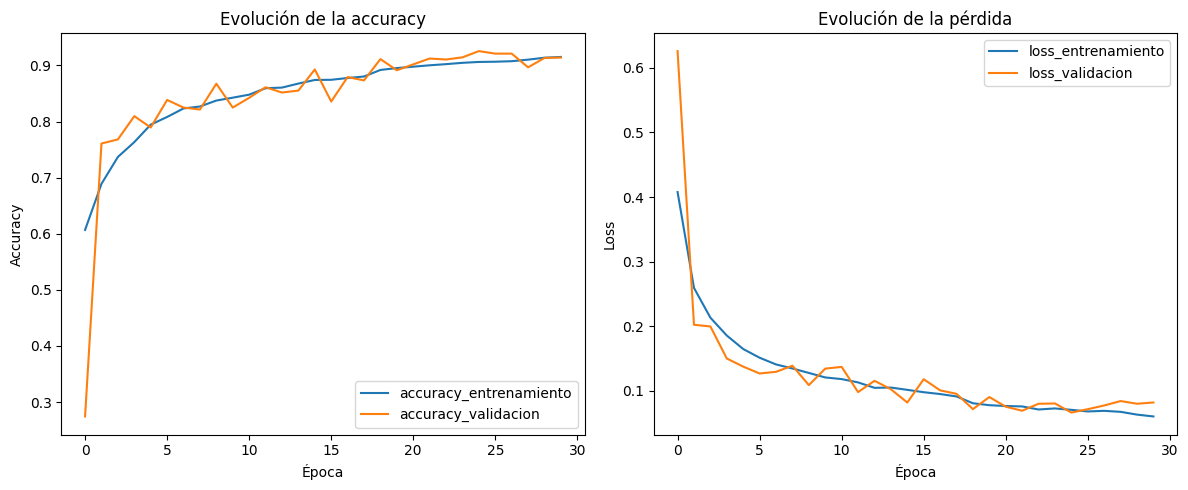

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(historial.history["accuracy"], label="accuracy_entrenamiento")
plt.plot(historial.history["val_accuracy"], label="accuracy_validacion")
plt.title("Evolución de la accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(historial.history["loss"], label="loss_entrenamiento")
plt.plot(historial.history["val_loss"], label="loss_validacion")
plt.title("Evolución de la pérdida")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

CELDA 20 — Evaluar en test

Aqui basicamente se coje el mejor moelo guardado y se prueba con las imagenes guardadas para test

Como podemos ver, el accuracy y la perdida son similares a los alcanzados en el entrenamiento, lo que valida la prediccion de nuestro modelo.

In [ ]:
perdida_test, accuracy_test = modelo.evaluate(dataset_test,verbose=1)

print("Pérdida en test:", perdida_test)
print("Accuracy en test:", accuracy_test)

180/180 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9078 - loss: 0.0695
Pérdida en test: 0.06950229406356812
Accuracy en test: 0.9077939987182617


CELDA 21 — Reporte por clase

In [ ]:
import tensorflow as tf
mejor_modelo = tf.keras.models.load_model(
    str(RUTA_MEJOR_MODELO),
    compile=False
)

print("Mejor modelo cargado correctamente desde:")
print(RUTA_MEJOR_MODELO)

Mejor modelo cargado correctamente desde:
/content/drive/MyDrive/TFG/modelos con 2 datasets/mejor_modelo_radiografias_2_datasets.keras


In [ ]:
etiquetas_reales = []
predicciones_modelo = []

for imagenes, etiquetas in dataset_test:
    probabilidades = mejor_modelo.predict(imagenes, verbose=0)
    clases_predichas = np.argmax(probabilidades, axis=1)

    etiquetas_reales.extend(etiquetas.numpy())
    predicciones_modelo.extend(clases_predichas)

etiquetas_reales = np.array(etiquetas_reales)
predicciones_modelo = np.array(predicciones_modelo)

reporte = classification_report(
    etiquetas_reales,
    predicciones_modelo,
    labels=list(range(len(CLASES))),
    target_names=CLASES,
    digits=4,
    zero_division=0
)

print(reporte)

                     precision    recall  f1-score   support

              COVID     0.9624    0.8950    0.9275       543
             Normal     0.9618    0.9834    0.9725      1690
    Viral Pneumonia     0.7456    0.7079    0.7262       356
Bacterial Pneumonia     0.6898    0.7333    0.7109       285

           accuracy                         0.9078      2874
          macro avg     0.8399    0.8299    0.8343      2874
       weighted avg     0.9082    0.9078    0.9075      2874



In [ ]:
df_resultados_test = pd.DataFrame({
    "ruta": RUTAS_TEST,
    "etiqueta_real": etiquetas_reales,
    "prediccion": predicciones_modelo
})

df_resultados_test["clase_real"] = df_resultados_test["etiqueta_real"].apply(
    lambda indice: CLASES[indice]
)

df_resultados_test["clase_predicha"] = df_resultados_test["prediccion"].apply(
    lambda indice: CLASES[indice]
)

df_resultados_test["origen"] = df_resultados_test["ruta"].apply(
    lambda ruta: "dataset_extra" if "dataset_extra" in Path(ruta).name.lower() else "dataset_principal"
)

df_resultados_test["acierto"] = (
    df_resultados_test["etiqueta_real"] == df_resultados_test["prediccion"]
)

print("Accuracy por origen:")

accuracy_por_origen = (
    df_resultados_test
    .groupby("origen")["acierto"]
    .mean()
    .reset_index(name="accuracy")
)

display(accuracy_por_origen)

print("\nConteo por origen y clase real:")

conteo_origen_clase = (
    df_resultados_test
    .groupby(["origen", "clase_real"])
    .size()
    .reset_index(name="cantidad")
)

display(conteo_origen_clase)

Accuracy por origen:


,origen,accuracy
0,dataset_extra,0.783333
1,dataset_principal,0.940633



Conteo por origen y clase real:


,origen,clase_real,cantidad
0,dataset_extra,Bacterial Pneumonia,285
1,dataset_extra,Normal,161
2,dataset_extra,Viral Pneumonia,154
3,dataset_principal,COVID,543
4,dataset_principal,Normal,1529
5,dataset_principal,Viral Pneumonia,202


In [ ]:
for origen in sorted(df_resultados_test["origen"].unique()):
    print("\n" + "=" * 80)
    print("Reporte para:", origen)
    print("=" * 80)

    df_origen = df_resultados_test[df_resultados_test["origen"] == origen]

    y_real_origen = df_origen["etiqueta_real"].to_numpy()
    y_pred_origen = df_origen["prediccion"].to_numpy()

    reporte_origen = classification_report(
        y_real_origen,
        y_pred_origen,
        labels=list(range(len(CLASES))),
        target_names=CLASES,
        digits=4,
        zero_division=0
    )

    print(reporte_origen)


Reporte para: dataset_extra
                     precision    recall  f1-score   support

              COVID     0.0000    0.0000    0.0000         0
             Normal     0.9500    0.9441    0.9470       161
    Viral Pneumonia     0.5798    0.7078    0.6374       154
Bacterial Pneumonia     0.8327    0.7333    0.7799       285

           accuracy                         0.7833       600
          macro avg     0.5906    0.5963    0.5911       600
       weighted avg     0.7992    0.7833    0.7882       600


Reporte para: dataset_principal
                     precision    recall  f1-score   support

              COVID     0.9643    0.8950    0.9284       543
             Normal     0.9630    0.9876    0.9751      1529
    Viral Pneumonia     0.9533    0.7079    0.8125       202
Bacterial Pneumonia     0.0000    0.0000    0.0000         0

           accuracy                         0.9406      2274
          macro avg     0.7202    0.6476    0.6790      2274
       weighted av

CELDA 22 — Matriz de confusión

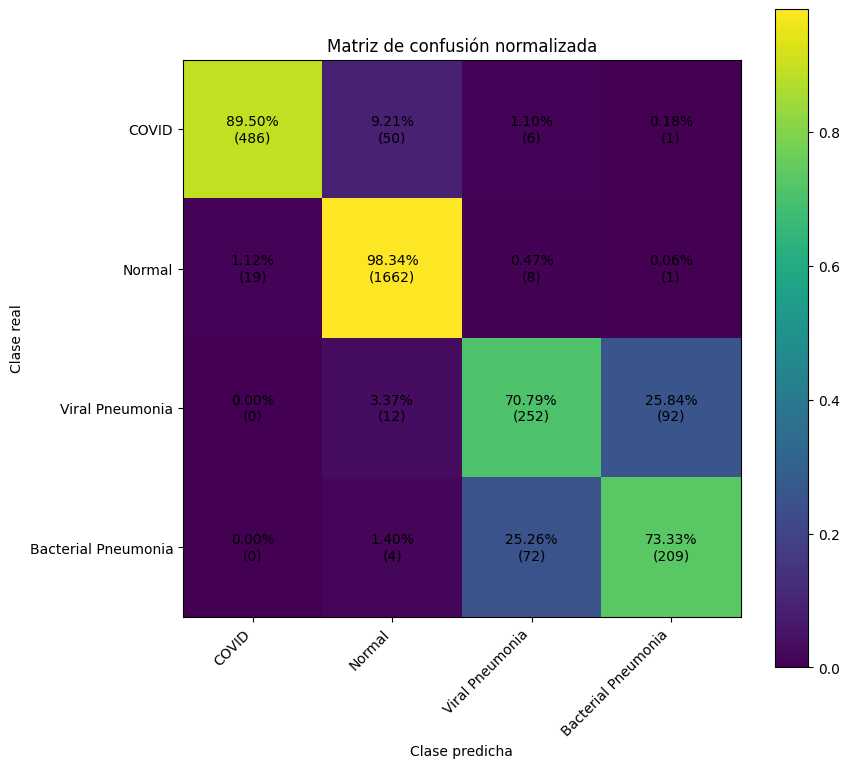

In [ ]:
matriz_confusion = confusion_matrix(
    etiquetas_reales,
    predicciones_modelo,
    labels=list(range(len(CLASES)))
)

matriz_confusion_normalizada = (
    matriz_confusion.astype("float")
    / matriz_confusion.sum(axis=1)[:, np.newaxis]
)

figura, eje = plt.subplots(figsize=(9, 8))

imagen = eje.imshow(matriz_confusion_normalizada)

eje.set_title("Matriz de confusión normalizada")
eje.set_xlabel("Clase predicha")
eje.set_ylabel("Clase real")

eje.set_xticks(np.arange(len(CLASES)))
eje.set_yticks(np.arange(len(CLASES)))

eje.set_xticklabels(CLASES, rotation=45, ha="right")
eje.set_yticklabels(CLASES)

for i in range(len(CLASES)):
    for j in range(len(CLASES)):
        porcentaje = matriz_confusion_normalizada[i, j] * 100
        valor_absoluto = matriz_confusion[i, j]

        texto = f"{porcentaje:.2f}%\n({valor_absoluto})"

        eje.text(
            j,
            i,
            texto,
            ha="center",
            va="center"
        )

plt.colorbar(imagen)
plt.tight_layout()
plt.show()

CELDA 23 — Guardar modelo final

In [ ]:
modelo.save(str(RUTA_MODELO_FINAL))

print("Modelo final guardado en:", RUTA_MODELO_FINAL)

Modelo final guardado en: /content/drive/MyDrive/TFG/modelos con 2 datasets/modelo_final_radiografias_2_datasets.keras
